# Concept Score Plotting Helpers

Utility functions for exploring `interp_results.json`.

In [29]:
import json
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


def load_interp_results(path="../experiments/artifacts/interp_results.json"):
    p = Path(path)
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f"Expected list in {p}, got {type(data).__name__}")
    return data


def count_entries_for_layer_k(results, layer, k):
    """Return count of entries matching (layer, K)."""
    return sum(1 for e in results if int(e.get("layer", -1)) == int(layer) and int(e.get("K", -1)) == int(k))


def count_entries_by_layer_k(results):
    """Return {(layer, K): count} for all pairs found."""
    counts = Counter((int(e["layer"]), int(e["K"])) for e in results if "layer" in e and "K" in e)
    return dict(sorted(counts.items(), key=lambda kv: (kv[0][0], kv[0][1])))


def _safe_mean(values):
    vals = [float(v) for v in values if v is not None]
    return float(np.mean(vals)) if vals else np.nan


def _cosine_list(score_dict):
    if not isinstance(score_dict, dict):
        return []
    cos = score_dict.get("cosine", [])
    return cos if isinstance(cos, list) else []


def build_log_ratio_dataframe(results, eps=1e-12, k_values=None, layers=None):
    """
    Build per-entry dataframe with:
      log_ratio = log(avg(scores.cosine) / avg(random_scores.cosine))

    Returns columns: layer, K, h_row, log_ratio
    """
    allowed_k = None if k_values is None else set(int(k) for k in k_values)
    allowed_layers = None if layers is None else set(int(l) for l in layers)

    rows = []
    for idx, e in enumerate(results):
        if "layer" not in e or "K" not in e:
            continue

        layer = int(e["layer"])
        k = int(e["K"])
        if allowed_k is not None and k not in allowed_k:
            continue
        if allowed_layers is not None and layer not in allowed_layers:
            continue

        s_avg = _safe_mean(_cosine_list(e.get("scores", {})))
        r_avg = _safe_mean(_cosine_list(e.get("random_scores", {})))
        if np.isnan(s_avg) or np.isnan(r_avg):
            continue

        ratio = (s_avg + eps) / (r_avg + eps)
        if ratio <= 0:
            continue

        rows.append({
            "layer": layer,
            "K": k,
            "h_row": int(e.get("h_row", idx)),
            "log_ratio": math.log(ratio),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No valid rows found after filtering; cannot build dataframe.")

    return df.sort_values(["K", "layer", "h_row"]).reset_index(drop=True)


In [30]:
def plot_log_scores_vs_layers_by_k(
    results,
    plot_type="line",
    k_values=None,
    layers=None,
    agg="mean",
    ci=95,
    eps=1e-12,
    ncols=2,
    figsize_per_plot=(6, 4),
    style="white",
):
    """
    Production-grade plotting helper:
    - Computes per-entry log-ratio score
    - Creates separate subplot per K
    - X-axis = layer, Y-axis = log_ratio

    plot_type:
      - 'line' : aggregated by layer per K (mean/median)
      - 'bar'  : aggregated by layer per K (mean/median)
      - 'box'  : distribution by layer per K

    Returns: (df, fig, axes)
      df is per-entry dataframe with columns [layer, K, h_row, log_ratio].
    """
    valid_plot_types = {"line", "bar", "box"}
    if plot_type not in valid_plot_types:
        raise ValueError(f"plot_type must be one of {valid_plot_types}, got: {plot_type}")
    if agg not in {"mean", "median"}:
        raise ValueError("agg must be 'mean' or 'median'")

    sns.set_theme(style=style)
    df = build_log_ratio_dataframe(results, eps=eps, k_values=k_values, layers=layers)

    ks = sorted(df["K"].unique().tolist())
    n = len(ks)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    agg_label = "mean" if agg == "mean" else "median"

    for i, k in enumerate(ks):
        ax = axes_flat[i]
        sub = df[df["K"] == k].copy()

        if plot_type == "box":
            sns.boxplot(data=sub, x="layer", y="log_ratio", ax=ax, color="steelblue", width=0.45, showfliers=False)
            ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
            ax.set_title(f"K={k} | Distribution")
        else:
            grouped = sub.groupby("layer", as_index=False)["log_ratio"]
            if agg == "mean":
                plot_df = grouped.mean()
            else:
                plot_df = grouped.median()

            if plot_type == "line":
                sns.lineplot(data=plot_df, x="layer", y="log_ratio", marker="o", ax=ax, color="steelblue")
                if ci and agg == "mean":
                    sns.lineplot(data=sub, x="layer", y="log_ratio", estimator="mean", errorbar=("ci", ci), ax=ax, color="steelblue", alpha=0.25, legend=False)
                ax.set_title(f"K={k}")
            elif plot_type == "bar":
                sns.barplot(data=plot_df, x="layer", y="log_ratio", ax=ax, color="steelblue", width=0.55)
                ax.set_title(f"K={k}")

        ax.set_xlabel("Layer")
        ax.set_ylabel("Concept detection")
        ax.grid(False)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

    # Hide any unused subplot slots
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle("Concept detection scores vs layers", y=1.02, fontsize=13)
    fig.tight_layout()
    return df, fig, axes


# Example usage:
results = load_interp_results("../experiments/artifacts/interp_results.json")


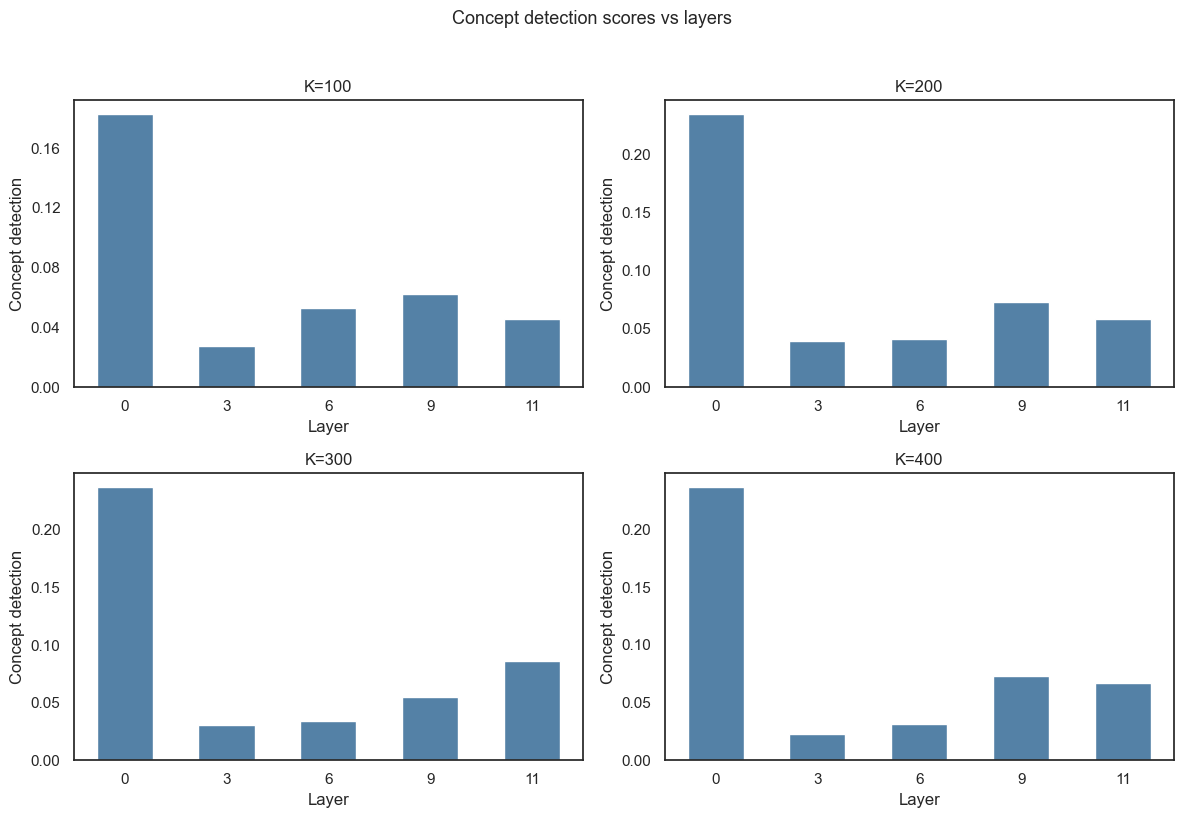

In [31]:
df, fig, axes = plot_log_scores_vs_layers_by_k(results, plot_type="bar", agg="mean")

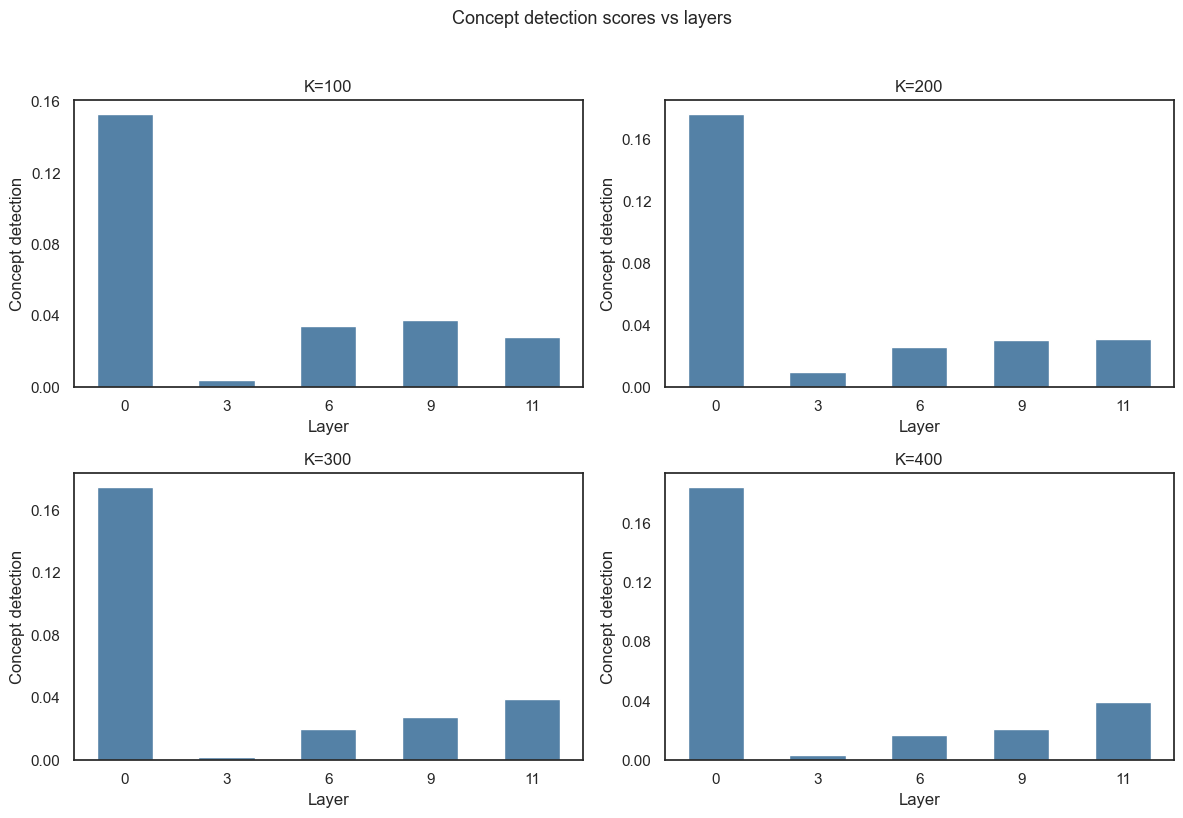

In [32]:
df, fig, axes = plot_log_scores_vs_layers_by_k(results, plot_type="bar", agg="median")

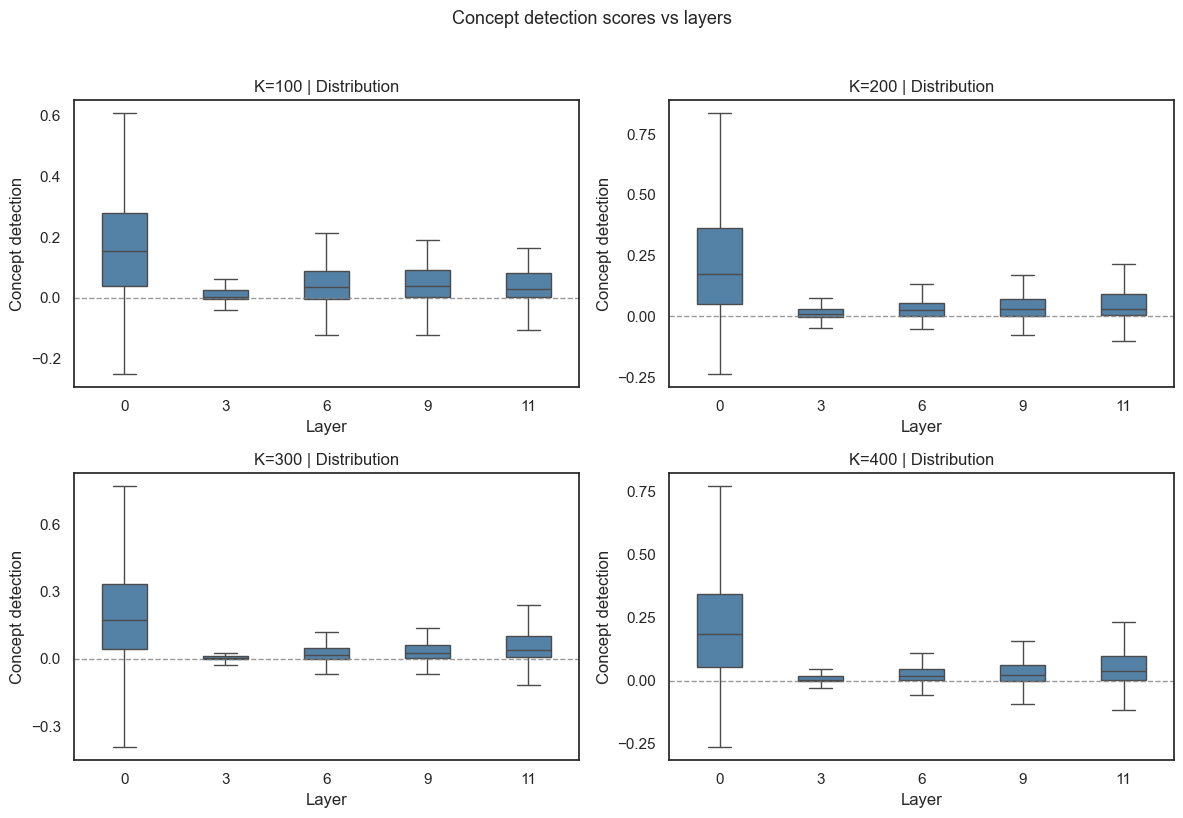

In [33]:
df, fig, axes = plot_log_scores_vs_layers_by_k(results, plot_type="box")

In [34]:
# Existing helper usage
results = load_interp_results("../experiments/artifacts/interp_results.json")
print("Entries for layer=0, K=100:", count_entries_for_layer_k(results, layer=0, k=100))
print("Total (layer, K) pairs:", len(count_entries_by_layer_k(results)))

pair_counts = count_entries_by_layer_k(results)
if not pair_counts:
    print("No (layer, K) entries found.")
else:
    print(f"{'Layer':>7}  {'K':>6}  {'Count':>8}")
    print("-" * 25)
    for (layer, k), count in pair_counts.items():
        print(f"{layer:>7}  {k:>6}  {count:>8}")


Entries for layer=0, K=100: 200
Total (layer, K) pairs: 20
  Layer       K     Count
-------------------------
      0     100       200
      0     200       400
      0     300       600
      0     400       800
      3     100       200
      3     200       400
      3     300       600
      3     400       800
      6     100       200
      6     200       400
      6     300       600
      6     400       800
      9     100       200
      9     200       400
      9     300       600
      9     400       800
     11     100       200
     11     200       400
     11     300       600
     11     400       800
